In [30]:
# Import Necessary Packages
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Load Data
file_path = "steps_tracker_dataset.csv"
df = pd.read_csv(file_path)

In [3]:
# Display basic info
print("Dataset Overview:")
print(df.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 500 non-null    object 
 1   steps                500 non-null    int64  
 2   distance_km          500 non-null    float64
 3   calories_burned      500 non-null    float64
 4   active_minutes       500 non-null    int64  
 5   sleep_hours          500 non-null    float64
 6   water_intake_liters  500 non-null    float64
 7   mood                 500 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 31.4+ KB
None


In [4]:
# Convert date to datetime format (to enable time-based grouping if needed)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [5]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
missing_values

date                   0
steps                  0
distance_km            0
calories_burned        0
active_minutes         0
sleep_hours            0
water_intake_liters    0
mood                   0
dtype: int64

In [6]:
# Handle missing values
df.dropna(inplace=True)

In [7]:
# Check for duplicate rows and remove them
df.drop_duplicates(inplace=True)

In [8]:
# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                             date         steps  distance_km  calories_burned  \
count                         500    500.000000   500.000000       500.000000   
mean   2022-07-02 06:54:43.200000  10238.572000     7.678800       307.157160   
min           2022-01-04 00:00:00     26.000000     0.020000         0.780000   
25%           2022-04-01 00:00:00   5313.250000     3.985000       159.397500   
50%           2022-06-28 00:00:00  10699.000000     8.025000       320.970000   
75%           2022-10-01 00:00:00  15317.500000    11.490000       459.525000   
max           2022-12-30 00:00:00  19979.000000    14.980000       599.370000   
std                           NaN   5829.268207     4.371964       174.878046   

       active_minutes  sleep_hours  water_intake_liters  
count       500.00000   500.000000           500.000000  
mean        102.40800     7.292400             2.506580  
min           0.00000     3.100000             0.040000  
25%          53.0

In [9]:
# Display the first few rows of the cleaned data set
df.head()

,date,steps,distance_km,calories_burned,active_minutes,sleep_hours,water_intake_liters,mood
0,2022-10-08,4147,3.11,124.41,41,10.5,3.77,stressed
1,2022-06-11,323,0.24,9.69,3,6.0,1.90,sad
2,2022-01-28,6622,4.97,198.66,66,6.0,4.48,sad
3,2022-03-23,11136,8.35,334.08,111,8.0,1.08,tired
4,2022-05-20,2718,2.04,81.54,27,4.9,1.00,tired


In [10]:
# Display the row and column count of the cleaned data set
df.shape

(500, 8)

In [11]:
# Encode the mood column and define mood severity scale
mood_order = {'happy': 0, 'neutral': 1, 'tired': 2, 'sad': 3, 'stressed': 4}
df['mood_encoded'] = df['mood'].map(mood_order)

In [12]:
# Select relevant features for clustering
features = ['steps', 'active_minutes', 'sleep_hours', 'mood_encoded']
X = df[features]

In [13]:
# Normalize/standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Create rolling windows or sequences if analyzing periods
rolling_df = df.copy()
rolling_df[['steps_avg', 'active_minutes_avg', 'sleep_hours_avg', 'mood_avg']] = (
    df[['steps', 'active_minutes', 'sleep_hours', 'mood_encoded']].rolling(window=3).mean()
)
rolling_df.dropna(inplace=True)

In [15]:
# Final dataset for clustering:
clustering_data = rolling_df[['steps_avg', 'active_minutes_avg', 'sleep_hours_avg', 'mood_avg']]

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


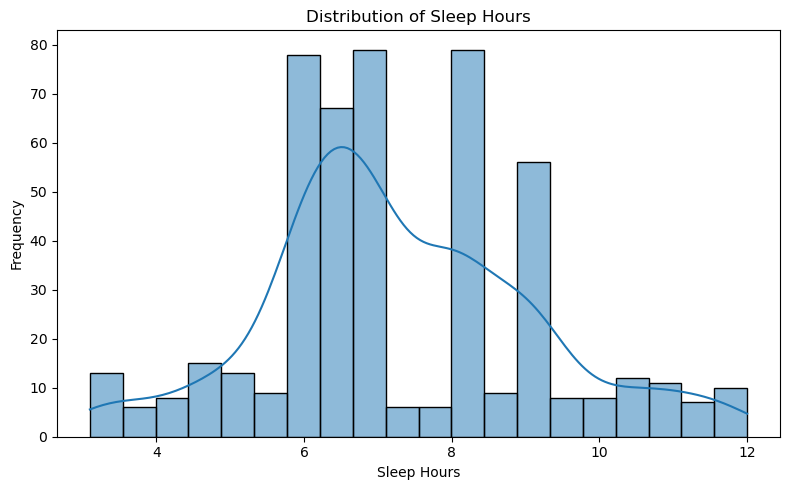

In [16]:
# Distribution of sleep hours
plt.figure(figsize=(8, 5))
sns.histplot(df['sleep_hours'], bins=20, kde=True)
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

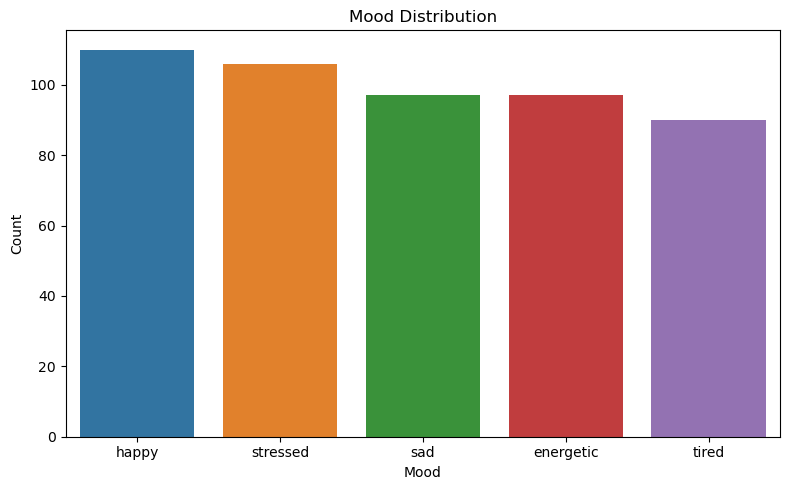

In [17]:
# Mood count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='mood', data=df, order=df['mood'].value_counts().index)
plt.title('Mood Distribution')
plt.xlabel('Mood')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

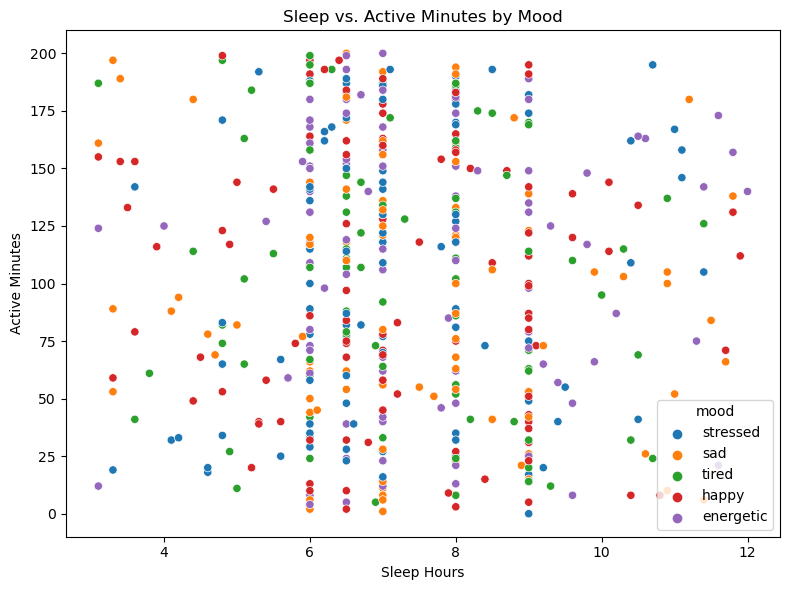

In [18]:
# Scatter plot - Sleep vs. Active Minutes colored by Mood
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='sleep_hours', y='active_minutes', hue='mood')
plt.title('Sleep vs. Active Minutes by Mood')
plt.xlabel('Sleep Hours')
plt.ylabel('Active Minutes')
plt.tight_layout()
plt.show()

In [20]:
# Drop any remaining rows with NaN values before clustering
clustering_data_clean = clustering_data.dropna()

In [22]:
# Re-standardize after dropping NaNs
X_scaled_clean = scaler.fit_transform(clustering_data_clean)

In [23]:
# Run KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled_clean)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


In [24]:
# Add cluster labels back to the cleaned rolling_df
rolling_df_clean = rolling_df.loc[clustering_data_clean.index].copy()
rolling_df_clean['cluster'] = clusters

In [25]:
# Show updated cluster counts
rolling_df_clean['cluster'].value_counts().sort_index()

cluster
0     92
1     66
2    106
Name: count, dtype: int64

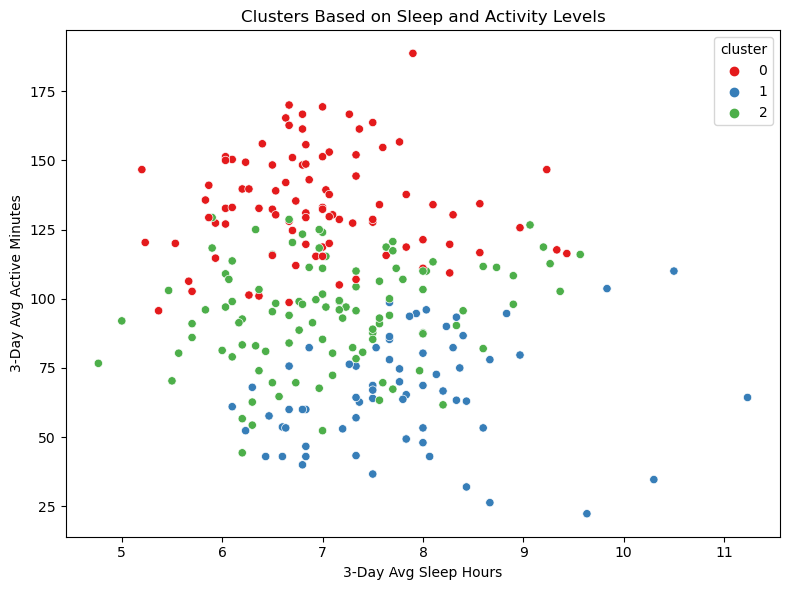

In [29]:
# Scatter plot: Sleep vs. Active Minutes colored by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rolling_df_clean,
    x='sleep_hours_avg',
    y='active_minutes_avg',
    hue='cluster',
    palette='Set1'
)
plt.title("Clusters Based on Sleep and Activity Levels")
plt.xlabel("3-Day Avg Sleep Hours")
plt.ylabel("3-Day Avg Active Minutes")
plt.tight_layout()
plt.show()

In [31]:
# Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=3)
rolling_df_clean['agglo_cluster'] = agglo.fit_predict(X_scaled_clean)

In [32]:
# Show cluster counts
rolling_df_clean['agglo_cluster'].value_counts().sort_index()

agglo_cluster
0    116
1     92
2     56
Name: count, dtype: int64

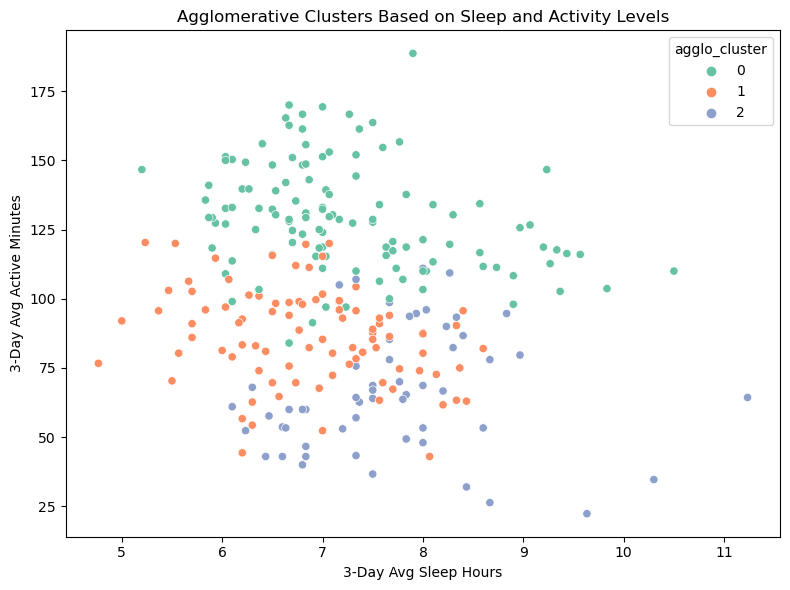

In [33]:
# Visualize Agglomerative Clustering results using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rolling_df_clean,
    x='sleep_hours_avg',
    y='active_minutes_avg',
    hue='agglo_cluster',
    palette='Set2'
)
plt.title("Agglomerative Clusters Based on Sleep and Activity Levels")
plt.xlabel("3-Day Avg Sleep Hours")
plt.ylabel("3-Day Avg Active Minutes")
plt.tight_layout()
plt.show()